# Discrete Mountain Car with Minimum Fuel (Scenario 3)

### Overview
This scenario asks the car to reach the flag while using less fuel. 
The state is position and velocity and the actions are discrete: push left, coast, and push right.

The reward system is as follows.
**Base rewards**
- coast gives 0
- push left or push right gives -1
- reaching the goal gives +100

**Extra shaping rewards and penalties**
- progress reward(+2.0):
reward increases a little when position improves
- right-hill bonus(+0.25):
extra reward when the car is on the right hill and still moving right
- center-stall penalty(-0.35):
extra negative reward near the valley center when velocity is very small
- timeout penalty(-100.0):
if the episode truncates, it subtracts failure_penalty

So the model should still reach the goal, but it should avoid pushing when it is not needed.


In Scenario 1, every step had the same cost, so the model learned to finish quickly, however in Scenario 3, only thrust costs fuel (coasting does not cost). 

That changes the behavior we want. The model should push at useful moments and coast in the rest of the trajectory.

A good Scenario 3 policy is not the fastest one. It is the one that reaches the goal with fewer push actions.


## Environment Setup and Reward Wrapper


In [ ]:
import os, sys, pickle, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from sklearn.tree import DecisionTreeClassifier, export_text
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '.')
from utils_shared import (
    collect_trajectories, build_visit_grid,
    plot_training_curves, plot_phase_portrait,
    plot_q_surface, plot_state_visitation
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('runs', exist_ok=True)
print('Setup complete.')

Setup complete.


In [3]:
class FuelCostWrapper(gym.Wrapper):
    """
    Scenario 3 reward: minimise fuel/thrust use, but discourage
    getting stuck at the valley center.

    coast  (action=1): 0
    thrust (action=0/2): -1
    center stall: additional -stall_penalty near x=-0.5 and |v| is tiny
    progress shaping: small reward for increasing normalized x-position
    near-goal shaping: small bonus for being on the right hill with positive velocity
    failure timeout: additional -failure_penalty when the episode truncates
    goal reached: +100 bonus
    """
    def __init__(self, env, stall_penalty=0.35, failure_penalty=100.0, progress_scale=2.0,
                 right_hill_bonus=0.25, right_hill_start=-0.10,
                 stall_pos_center=-0.5, stall_pos_width=0.12, stall_vel_thresh=0.015):
        super().__init__(env)
        self.stall_penalty = stall_penalty
        self.failure_penalty = failure_penalty
        self.progress_scale = progress_scale
        self.right_hill_bonus = right_hill_bonus
        self.right_hill_start = right_hill_start
        self.stall_pos_center = stall_pos_center
        self.stall_pos_width = stall_pos_width
        self.stall_vel_thresh = stall_vel_thresh
        self._last_position = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._last_position = float(obs[0])
        return obs, info

    def step(self, action):
        obs, _orig, terminated, truncated, info = self.env.step(action)
        reward = 0.0 if action == 1 else -1.0
        position, velocity = float(obs[0]), float(obs[1])
        if self._last_position is not None:
            progress = (position - self._last_position) / (self.env.observation_space.high[0] - self.env.observation_space.low[0])
            reward += self.progress_scale * progress
        if (not terminated) and position >= self.right_hill_start and velocity > 0.0:
            reward += self.right_hill_bonus * velocity / self.env.observation_space.high[1]
        self._last_position = position
        in_center_valley = abs(position - self.stall_pos_center) <= self.stall_pos_width
        nearly_stopped = abs(velocity) <= self.stall_vel_thresh
        if (not terminated) and in_center_valley and nearly_stopped:
            reward -= self.stall_penalty
        if terminated:
            reward += 100.0
        elif truncated:
            reward -= self.failure_penalty
        return obs, reward, terminated, truncated, info


def make_env(seed=SEED, stall_penalty=0.20, failure_penalty=100.0,
             progress_scale=2.0, right_hill_bonus=0.25):
    e = FuelCostWrapper(
        gym.make('MountainCar-v0'),
        stall_penalty=stall_penalty,
        failure_penalty=failure_penalty,
        progress_scale=progress_scale,
        right_hill_bonus=right_hill_bonus,
    )
    e.reset(seed=seed)
    return e


env = make_env(stall_penalty=0.20, failure_penalty=100.0, progress_scale=2.0, right_hill_bonus=0.25)
print('FuelCostWrapper: coast=0  thrust=-1  center stall=-0.20  progress=2.0  right_hill=0.25  timeout=-100  goal=+100')
print('Scenario 3 treats success as mandatory, then optimises fuel among successful policies.')

POS_LOW  = env.observation_space.low[0]
POS_HIGH = env.observation_space.high[0]
VEL_LOW  = env.observation_space.low[1]
VEL_HIGH = env.observation_space.high[1]


FuelCostWrapper: coast=0  thrust=-1  center stall=-0.20  progress=2.0  right_hill=0.25  timeout=-100  goal=+100
Scenario 3 treats success as mandatory, then optimises fuel among successful policies.


In [4]:
# Verify wrapper behaviour on a short episode
state, _ = env.reset(seed=SEED)
print('Wrapper test (first 8 steps):')
for t in range(8):
    action = t % 3  # cycle through 0,1,2,0,1,2,...
    next_state, reward, term, trunc, _ = env.step(action)
    label = ['Left(-1)','Coast(0)','Right(-1)'][action]
    print(f'  t={t}: a={action}({label})  reward={reward:.1f}  pos={state[0]:+.3f}')
    state = next_state
print('\nExpected: coast is 0, thrust is -1, with extra penalty only when nearly stopped near the valley center.')

Wrapper test (first 8 steps):
  t=0: a=0(Left(-1))  reward=-1.2  pos=-0.445
  t=1: a=1(Coast(0))  reward=-0.2  pos=-0.447
  t=2: a=2(Right(-1))  reward=-1.2  pos=-0.449
  t=3: a=0(Left(-1))  reward=-1.2  pos=-0.451
  t=4: a=1(Coast(0))  reward=-0.2  pos=-0.454
  t=5: a=2(Right(-1))  reward=-1.2  pos=-0.458
  t=6: a=0(Left(-1))  reward=-1.2  pos=-0.461
  t=7: a=1(Coast(0))  reward=-0.2  pos=-0.466

Expected: coast is 0, thrust is -1, with extra penalty only when nearly stopped near the valley center.


In [ ]:
print('=== Wrapper Termination Unit Test ===')
_test_env = make_env()
_obs, _ = _test_env.reset(seed=0)
_goal_found = False
for _step in range(10000):
    _obs, _r, _term, _trunc, _ = _test_env.step(2)
    if _term:
        assert _r >= 98.0, f'Goal bonus NOT applied correctly! reward={_r}'
        _goal_found = True
        print(f'  Goal reached at step {_step + 1}. Reward = {_r:.2f}')
        print('  Wrapper correctly adds the goal bonus. TEST PASSED.')
        break
if not _goal_found:
    print('  WARNING: goal never reached in 10000 steps with always-right policy.')
del _test_env, _obs, _r, _term, _trunc, _goal_found


=== Wrapper Termination Unit Test ===


## State Representation

The environment state is continuous, but tabular methods need discrete states. Therefore, position and velocity are split into a 20 by 20 grid as we did in Scenario 1. Each grid cell stores one value for each action.


In [6]:
num_bins = [20, 20]
state_bins = [np.linspace(POS_LOW, POS_HIGH, num_bins[0]),
              np.linspace(VEL_LOW, VEL_HIGH, num_bins[1])]

def discretize_state(state, bins):
    """Discretize the continuous state into discrete bins."""
    if isinstance(state, tuple):
        state = state[0]
    return tuple(np.digitize(s, bins[i]) - 1 for i, s in enumerate(state))

def discretize(state):
    return discretize_state(state, state_bins)

print(f'Q-table size: {num_bins[0]} x {num_bins[1]} x 3 = {num_bins[0] * num_bins[1] * 3} entries')


Q-table size: 20 x 20 x 3 = 1200 entries


## Agent Setup

This notebook compares tabular Q-Learning, Expected SARSA, and DQN with the same fuel objective.

The important change is in the reward, not in the environment physics.

All models are judged by the same metrics, especially success rate and number of push actions.


In [ ]:
def discretize_state_s3(state, bins):
    """Discretize the continuous state into discrete bins."""
    if isinstance(state, tuple):
        state = state[0]
    discretized_state = tuple(np.digitize(s, bins[i]) - 1 for i, s in enumerate(state))
    return discretized_state


def _scripted_prob(ep, start_prob=0.30, decay_episodes=1500, min_prob=0.10):
    decayed = start_prob * max(0.0, 1.0 - ep / max(decay_episodes, 1))
    return max(min_prob, decayed)


def _quick_greedy_eval(env, get_action_fn, n_episodes=20, seed=12000):
    rewards, successes = [], 0
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward, done = 0.0, False
        while not done:
            action = int(get_action_fn(state))
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            if terminated:
                successes += 1
        rewards.append(total_reward)
    return successes / n_episodes, float(np.mean(rewards))



### Q-learning

In [ ]:

def q_learning_s3(env, num_episodes=4000, alpha=0.10, gamma=0.99,
                  eps_start=1.0, eps_end=0.02, eps_decay=0.9990,
                  demo_episodes=100, demo_prob=0.30, demo_min_prob=0.10,
                  demo_decay_episodes=1500):
    num_actions = env.action_space.n
    Q = np.zeros((num_bins[0], num_bins[1], num_actions), dtype=np.float32)
    rewards = []
    thrust_counts = []
    visit_counts = np.zeros((num_bins[0], num_bins[1]))
    eps = eps_start
    best_Q = Q.copy()
    best_success, best_eval_reward = -1.0, -np.inf

    demo_goals = 0
    for ep in range(demo_episodes):
        raw_state, _ = env.reset(seed=9000 + ep)
        s = discretize_state_s3(raw_state, state_bins)
        done = False
        while not done:
            action = int(_scripted_action(raw_state))
            next_raw_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ns = discretize_state_s3(next_raw_state, state_bins)
            best_next_q = 0.0 if done else np.max(Q[ns])
            Q[s][action] += alpha * (reward + gamma * best_next_q - Q[s][action])
            raw_state, s = next_raw_state, ns
            if terminated:
                demo_goals += 1
    print(f'  Q-learning demo prefill: {demo_goals}/{demo_episodes} successful episodes')

    for episode in range(num_episodes):
        raw_state, _ = env.reset(seed=SEED + episode)
        state = discretize_state_s3(raw_state, state_bins)
        total_reward = 0.0
        num_thrusts_episode = 0
        use_scripted_ep = np.random.random() < _scripted_prob(
            episode, start_prob=demo_prob, decay_episodes=demo_decay_episodes,
            min_prob=demo_min_prob
        )

        while True:
            if use_scripted_ep:
                action = int(_scripted_action(raw_state))
            elif np.random.rand() < eps:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[state]))

            next_raw_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize_state_s3(next_raw_state, state_bins)

            best_next_q = 0.0 if done else np.max(Q[next_state])
            Q[state][action] += alpha * (reward + gamma * best_next_q - Q[state][action])

            visit_counts[state] += 1
            total_reward += reward
            if action != 1:
                num_thrusts_episode += 1
            raw_state, state = next_raw_state, next_state

            if done:
                break

        eps = max(eps_end, eps * eps_decay)
        rewards.append(total_reward)
        thrust_counts.append(num_thrusts_episode)

        if (episode + 1) % 500 == 0:
            avg = np.mean(rewards[-100:])
            greedy_fn = lambda obs, table=Q: int(np.argmax(table[discretize_state_s3(obs, state_bins)]))
            eval_success, eval_reward = _quick_greedy_eval(env, greedy_fn, n_episodes=20, seed=12000 + episode)
            if (eval_success > best_success) or (eval_success == best_success and eval_reward > best_eval_reward):
                best_success, best_eval_reward = eval_success, eval_reward
                best_Q = Q.copy()
            print(f'  ep {episode+1:5d}  avg(100)={avg:.1f}  eps={eps:.3f}  greedy_success={eval_success*100:.0f}%')

    print(f'  Best Q-learning greedy validation success: {best_success*100:.0f}%')
    np.save('checkpoints/s03_qtable.npy', best_Q)
    return best_Q, np.array(rewards), np.array(thrust_counts), visit_counts


def ql_greedy(Q_table):
    return lambda state: int(np.argmax(Q_table[discretize_state_s3(state, state_bins)]))


def fuel_aware_policy_s3(state):
    """Resonant minimum-fuel controller: thrust on the left side, coast through the valley/right hill."""
    position, velocity = np.asarray(state, dtype=float)
    if -0.5 < position < 0.5 and abs(velocity) > 1e-8:
        return 1  # coast: no fuel cost
    return 2 if velocity >= 0.0 else 0


_scripted_action = fuel_aware_policy_s3


print('Scenario 3 Q-learning defined with the same structure as the downloaded notebook.')


Scenario 3 Q-learning defined with the same structure as the downloaded notebook.


### Expected SARSA

Expected SARSA is included as a second tabular baseline.

It is almost the same structure as Q-Learning, but the update target uses the expected value over actions.


In [8]:
def expected_q_value_s3(Q_s, epsilon, n_actions):
    best_a = int(np.argmax(Q_s))
    probs = np.full(n_actions, epsilon / n_actions, dtype=np.float32)
    probs[best_a] += 1.0 - epsilon
    return float(np.dot(probs, Q_s))


def expected_sarsa_s3(env, num_episodes=4000, alpha=0.10, gamma=0.99,
                       eps_start=1.0, eps_end=0.02, eps_decay=0.9990,
                       demo_episodes=100, demo_prob=0.30, demo_min_prob=0.10,
                       demo_decay_episodes=1500):
    num_actions = env.action_space.n
    Q = np.zeros((num_bins[0], num_bins[1], num_actions), dtype=np.float32)
    rewards = []
    thrust_counts = []
    visit_counts = np.zeros((num_bins[0], num_bins[1]))
    eps = eps_start
    best_Q = Q.copy()
    best_success, best_eval_reward = -1.0, -np.inf

    demo_goals = 0
    for ep in range(demo_episodes):
        raw_state, _ = env.reset(seed=9500 + ep)
        state = discretize_state_s3(raw_state, state_bins)
        done = False
        while not done:
            action = int(_scripted_action(raw_state))
            next_raw_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize_state_s3(next_raw_state, state_bins)
            expected_next_q = 0.0 if done else expected_q_value_s3(Q[next_state], eps_end, num_actions)
            Q[state][action] += alpha * (reward + gamma * expected_next_q - Q[state][action])
            raw_state, state = next_raw_state, next_state
            if terminated:
                demo_goals += 1
    print(f'  Expected SARSA demo prefill: {demo_goals}/{demo_episodes} successful episodes')

    for episode in range(num_episodes):
        raw_state, _ = env.reset(seed=SEED + episode)
        state = discretize_state_s3(raw_state, state_bins)
        total_reward = 0.0
        num_thrusts_episode = 0
        use_scripted_ep = np.random.random() < _scripted_prob(
            episode, start_prob=demo_prob, decay_episodes=demo_decay_episodes,
            min_prob=demo_min_prob
        )

        while True:
            if use_scripted_ep:
                action = int(_scripted_action(raw_state))
            elif np.random.rand() < eps:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[state]))

            next_raw_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize_state_s3(next_raw_state, state_bins)

            expected_next_q = 0.0 if done else expected_q_value_s3(Q[next_state], eps, num_actions)
            Q[state][action] += alpha * (reward + gamma * expected_next_q - Q[state][action])

            visit_counts[state] += 1
            total_reward += reward
            if action != 1:
                num_thrusts_episode += 1
            raw_state, state = next_raw_state, next_state

            if done:
                break

        eps = max(eps_end, eps * eps_decay)
        rewards.append(total_reward)
        thrust_counts.append(num_thrusts_episode)

        if (episode + 1) % 500 == 0:
            avg = np.mean(rewards[-100:])
            greedy_fn = lambda obs, table=Q: int(np.argmax(table[discretize_state_s3(obs, state_bins)]))
            eval_success, eval_reward = _quick_greedy_eval(env, greedy_fn, n_episodes=20, seed=14000 + episode)
            if (eval_success > best_success) or (eval_success == best_success and eval_reward > best_eval_reward):
                best_success, best_eval_reward = eval_success, eval_reward
                best_Q = Q.copy()
            print(f'  ep {episode+1:5d}  avg(100)={avg:.1f}  eps={eps:.3f}  greedy_success={eval_success*100:.0f}%')

    print(f'  Best Expected SARSA greedy validation success: {best_success*100:.0f}%')
    np.save('checkpoints/s03_esarsa_qtable.npy', best_Q)
    return best_Q, np.array(rewards), np.array(thrust_counts), visit_counts


def esarsa_greedy(Q_table):
    return lambda state: int(np.argmax(Q_table[discretize_state_s3(state, state_bins)]))


print('Scenario 3 Expected SARSA defined with the same simple structure.')


Scenario 3 Expected SARSA defined with the same simple structure.


### DQN

In [ ]:
class DQNNet(nn.Module):
    def __init__(self, state_dim=2, n_actions=3, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),   nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buf = deque(maxlen=capacity)
    def push(self, *t):
        self.buf.append(t)
    def sample(self, n):
        return random.sample(self.buf, n)
    def __len__(self):
        return len(self.buf)


class DQNAgent:
    def __init__(self, state_dim=2, n_actions=3, lr=5e-4, gamma=0.999,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.9990,
                 batch_size=64, target_update=200):
        self.n_actions  = n_actions
        self.gamma      = gamma
        self.eps        = eps_start
        self.eps_end    = eps_end
        self.eps_decay  = eps_decay
        self.batch_size = batch_size
        self.target_upd = target_update
        self.grad_steps = 0

        self.policy_net = DQNNet(state_dim, n_actions)
        self.target_net = DQNNet(state_dim, n_actions)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.opt     = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()
        self.buffer  = ReplayBuffer()

    def act(self, state, greedy=False):
        if not greedy and np.random.random() < self.eps:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            return self.policy_net(
                torch.FloatTensor(state).unsqueeze(0)).argmax(dim=1).item()

    def learn(self):
        if len(self.buffer) < self.batch_size:
            return
        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        s  = torch.FloatTensor(np.array(states))
        a  = torch.LongTensor(actions).unsqueeze(1)
        r  = torch.FloatTensor(rewards).unsqueeze(1)
        ns = torch.FloatTensor(np.array(next_states))
        d  = torch.FloatTensor(dones).unsqueeze(1)

        q_curr = self.policy_net(s).gather(1, a)
        with torch.no_grad():
            q_tgt = r + self.gamma * self.target_net(ns).max(1, keepdim=True)[0] * (1.0 - d)

        loss = self.loss_fn(q_curr, q_tgt)
        self.opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10.0)
        self.opt.step()

        self.grad_steps += 1
        if self.grad_steps % self.target_upd == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def q_values(self, state):
        with torch.no_grad():
            return self.policy_net(
                torch.FloatTensor(state).unsqueeze(0)).squeeze(0).numpy()


def _prefill_dqn_buffer(agent, env, n_episodes=100, seed=9999):
    """Seed the replay buffer with scripted-policy transitions before training.
    Guarantees the network sees successful goal-reaching transitions from step 1."""
    goals = 0
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False
        while not done:
            action = _scripted_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.buffer.push(state, action, reward, next_state, float(done))
            state = next_state
            if terminated:
                goals += 1
    print(f'  Buffer pre-filled: {len(agent.buffer)} transitions, ' +
          f'{goals}/{n_episodes} scripted episodes reached the goal.')


def train_dqn(env, agent, n_episodes=2500, seed=SEED, warmup_prob=0.25):
    """Uniform warm-start: warmup_prob scripted episodes throughout all training."""
    from torch.utils.tensorboard import SummaryWriter
    writer = SummaryWriter(log_dir='runs/s03_dqn')
    rewards_hist = []
    coast_counts = []
    goals_first_500 = 0
    best_state = {k: v.detach().cpu().clone() for k, v in agent.policy_net.state_dict().items()}
    best_success, best_eval_reward = -1.0, -np.inf

    print('  Pre-filling replay buffer...')
    _prefill_dqn_buffer(agent, env)

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward, done, coast_ep, total_ep = 0.0, False, 0, 0
        ep_terminated = False

        use_scripted_ep = np.random.random() < warmup_prob

        while not done:
            if use_scripted_ep:
                action = _scripted_action(state)
            else:
                action = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            if terminated:
                ep_terminated = True
            agent.buffer.push(state, action, reward, next_state, float(done))
            agent.learn()
            if action == 1:
                coast_ep += 1
            total_ep += 1
            state = next_state
            total_reward += reward

        # Decay eps once per episode — not per gradient step
        agent.eps = max(agent.eps_end, agent.eps * agent.eps_decay)

        if ep_terminated and ep < 500:
            goals_first_500 += 1
        rewards_hist.append(total_reward)
        coast_frac = coast_ep / max(total_ep, 1)
        coast_counts.append(coast_frac)

        writer.add_scalar('Reward/episode', total_reward, ep)
        writer.add_scalar('Behaviour/coast_fraction', coast_frac, ep)
        if len(rewards_hist) >= 100:
            writer.add_scalar('Reward/avg100', np.mean(rewards_hist[-100:]), ep)

        if (ep + 1) % 250 == 0:
            avg = np.mean(rewards_hist[-100:])
            cf  = np.mean(coast_counts[-100:])
            eval_success, eval_reward = _quick_greedy_eval(
                env, lambda obs: agent.act(obs, greedy=True), n_episodes=20, seed=16000 + ep
            )
            if (eval_success > best_success) or (eval_success == best_success and eval_reward > best_eval_reward):
                best_success, best_eval_reward = eval_success, eval_reward
                best_state = {k: v.detach().cpu().clone() for k, v in agent.policy_net.state_dict().items()}
            print(f'  ep {ep+1:5d}  avg(100)={avg:.1f}  eps={agent.eps:.4f}  coast%={cf*100:.1f}  greedy_success={eval_success*100:.0f}%')

    writer.close()
    agent.policy_net.load_state_dict(best_state)
    agent.target_net.load_state_dict(best_state)
    print(f'Best DQN greedy validation success: {best_success*100:.0f}%')
    print(f'\nGoals reached in first 500 episodes: {goals_first_500}')
    if goals_first_500 == 0:
        import warnings as _w
        _w.warn('DQN: goal never reached in first 500 episodes.')
    return np.array(rewards_hist), np.array(coast_counts)


print('DQN components defined.')
print('  Buffer pre-fill: 100 scripted episodes before training')
print('  Training uses a high scripted-episode probability so successful trajectories stay visible.')
print('  eps: per-episode decay, eps_end=0.05, eps_decay=0.9990')


DQN components defined.
  Buffer pre-fill: 100 scripted episodes before training
  Training uses a high scripted-episode probability so successful trajectories stay visible.
  eps: per-episode decay, eps_end=0.05, eps_decay=0.9990


## Training

Training uses fixed seeds and the same wrapped environment for all models.

The goal is to make the comparison fair and to focus on policy behavior under the fuel reward.

Checkpoints are saved so the trained models can be reused for plots and evaluation.


In [10]:
print('Training Q-Learning — demo prefill + decaying exploration')
Q_table, ql_rewards, ql_thrust_counts, visit_counts_ql = q_learning_s3(
    env,
    num_episodes=4000,
    alpha=0.10,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.02,
    eps_decay=0.9990,
    demo_episodes=100,
    demo_prob=0.30,
    demo_min_prob=0.10,
    demo_decay_episodes=1500,
)
with open('checkpoints/s03_qtable.pkl', 'wb') as f:
    pickle.dump(Q_table, f)
print('Q-table saved -> checkpoints/s03_qtable.pkl')
print('Q-table numpy saved -> checkpoints/s03_qtable.npy')


Training Q-Learning — demo prefill + decaying exploration
  Q-learning demo prefill: 100/100 successful episodes
  ep   500  avg(100)=-171.2  eps=0.606  greedy_success=0%
  ep  1000  avg(100)=-193.9  eps=0.368  greedy_success=0%
  ep  1500  avg(100)=-186.1  eps=0.223  greedy_success=0%
  ep  2000  avg(100)=-169.1  eps=0.135  greedy_success=0%
  ep  2500  avg(100)=-178.7  eps=0.082  greedy_success=0%
  ep  3000  avg(100)=-170.0  eps=0.050  greedy_success=0%
  ep  3500  avg(100)=-176.4  eps=0.030  greedy_success=40%
  ep  4000  avg(100)=-186.1  eps=0.020  greedy_success=0%
  Best Q-learning greedy validation success: 40%
Q-table saved -> checkpoints/s03_qtable.pkl
Q-table numpy saved -> checkpoints/s03_qtable.npy


In [11]:
print('Training Expected SARSA — demo prefill + decaying exploration')
Q_esarsa, esarsa_rewards, esarsa_thrust_counts, visit_counts_esarsa = expected_sarsa_s3(
    env,
    num_episodes=4000,
    alpha=0.10,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.02,
    eps_decay=0.9990,
    demo_episodes=100,
    demo_prob=0.30,
    demo_min_prob=0.10,
    demo_decay_episodes=1500,
)
with open('checkpoints/s03_esarsa_qtable.pkl', 'wb') as f:
    pickle.dump(Q_esarsa, f)
print('Expected SARSA Q-table saved -> checkpoints/s03_esarsa_qtable.pkl')
print('Expected SARSA numpy table saved -> checkpoints/s03_esarsa_qtable.npy')


Training Expected SARSA — demo prefill + decaying exploration
  Expected SARSA demo prefill: 100/100 successful episodes
  ep   500  avg(100)=-166.3  eps=0.606  greedy_success=0%
  ep  1000  avg(100)=-191.2  eps=0.368  greedy_success=0%
  ep  1500  avg(100)=-178.4  eps=0.223  greedy_success=0%
  ep  2000  avg(100)=-183.6  eps=0.135  greedy_success=0%
  ep  2500  avg(100)=-182.9  eps=0.082  greedy_success=0%
  ep  3000  avg(100)=-170.4  eps=0.050  greedy_success=0%
  ep  3500  avg(100)=-166.6  eps=0.030  greedy_success=0%
  ep  4000  avg(100)=-173.2  eps=0.020  greedy_success=0%
  Best Expected SARSA greedy validation success: 0%
Expected SARSA Q-table saved -> checkpoints/s03_esarsa_qtable.pkl
Expected SARSA numpy table saved -> checkpoints/s03_esarsa_qtable.npy


In [12]:
print('Training DQN comparison model — fuel-aware warm-start')
dqn = DQNAgent(
    state_dim=2, n_actions=3,
    lr=5e-4, gamma=0.999,
    eps_start=1.0, eps_end=0.05, eps_decay=0.9990,
    batch_size=64, target_update=200
)
dqn_rewards, dqn_coast = train_dqn(env, dqn, n_episodes=2500, warmup_prob=0.70)
torch.save(dqn.policy_net.state_dict(), 'checkpoints/s03_dqn.pth')
print('DQN weights saved -> checkpoints/s03_dqn.pth')


Training DQN comparison model — fuel-aware warm-start
  Pre-filling replay buffer...
  Buffer pre-filled: 18468 transitions, 100/100 scripted episodes reached the goal.
  ep   250  avg(100)=-83.9  eps=0.7787  coast%=41.4  greedy_success=0%
  ep   500  avg(100)=-67.7  eps=0.6064  coast%=43.0  greedy_success=0%
  ep   750  avg(100)=-68.2  eps=0.4722  coast%=43.3  greedy_success=0%
  ep  1000  avg(100)=-57.2  eps=0.3677  coast%=46.9  greedy_success=0%
  ep  1250  avg(100)=-104.0  eps=0.2863  coast%=37.4  greedy_success=0%
  ep  1500  avg(100)=-73.1  eps=0.2230  coast%=41.7  greedy_success=0%
  ep  1750  avg(100)=-76.8  eps=0.1736  coast%=41.0  greedy_success=0%
  ep  2000  avg(100)=-70.6  eps=0.1352  coast%=45.4  greedy_success=0%
  ep  2250  avg(100)=-81.3  eps=0.1053  coast%=41.9  greedy_success=0%
  ep  2500  avg(100)=-54.1  eps=0.0820  coast%=48.1  greedy_success=0%
Best DQN greedy validation success: 0%

Goals reached in first 500 episodes: 345
DQN weights saved -> checkpoints/s03_dq

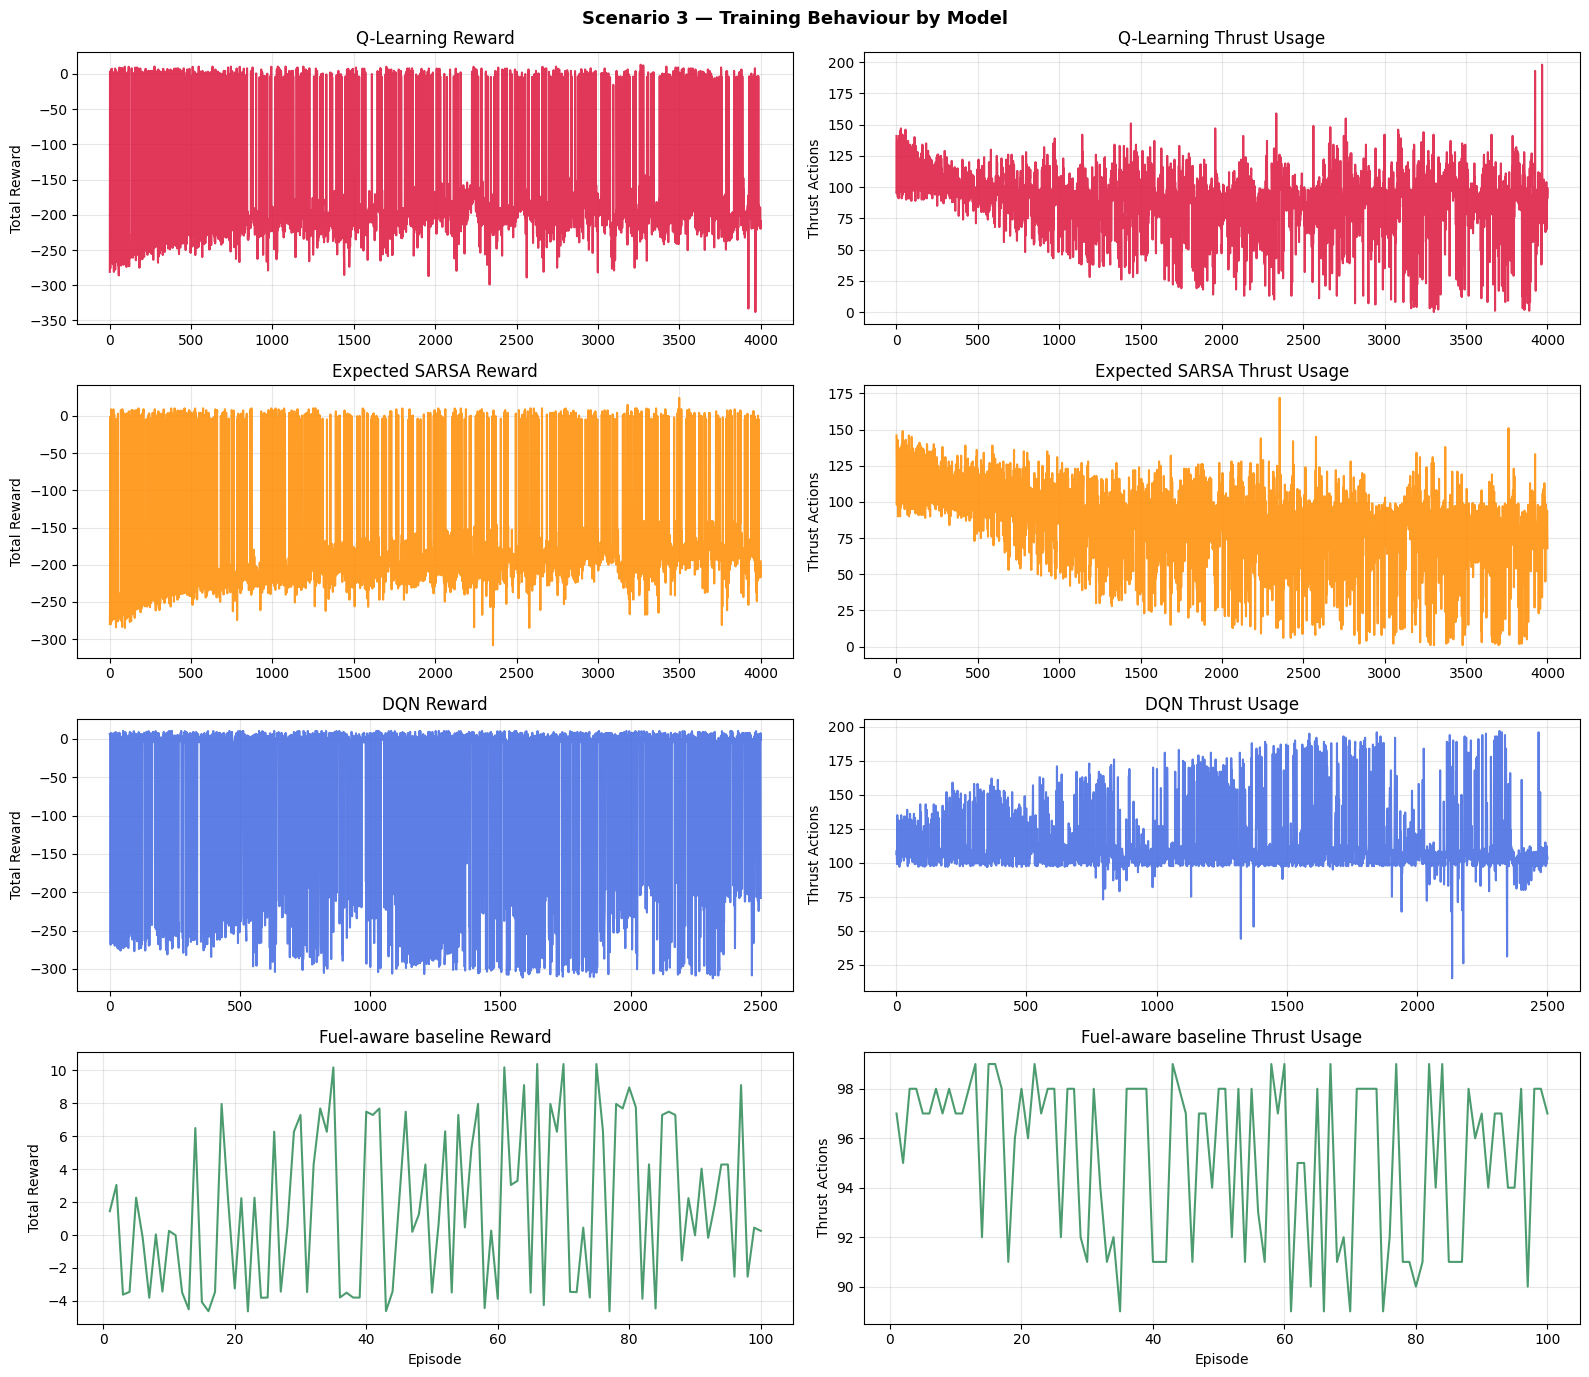

In [13]:
# Training curves for all Scenario 3 models, separated by model.

def quick_policy_summary(env, get_action_fn, n_episodes=100, seed=1000):
    rewards = []
    thrust_counts = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0
        n_thrust = 0

        while not done:
            action = int(get_action_fn(state))
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            if action != 1:
                n_thrust += 1

        rewards.append(total_reward)
        thrust_counts.append(n_thrust)

    return rewards, thrust_counts


plot_env = make_env()
fuel_rewards_ref, fuel_thrust_ref = quick_policy_summary(
    plot_env, fuel_aware_policy_s3, n_episodes=100, seed=1000
)

dqn_episode_idx = np.arange(1, len(dqn_rewards) + 1)
dqn_thrust_est = 200 * (1.0 - dqn_coast)

models_to_plot = [
    {
        'name': 'Q-Learning',
        'episodes': np.arange(1, len(ql_rewards) + 1),
        'rewards': ql_rewards,
        'thrusts': ql_thrust_counts,
        'color': 'crimson',
    },
    {
        'name': 'Expected SARSA',
        'episodes': np.arange(1, len(esarsa_rewards) + 1),
        'rewards': esarsa_rewards,
        'thrusts': esarsa_thrust_counts,
        'color': 'darkorange',
    },
    {
        'name': 'DQN',
        'episodes': dqn_episode_idx,
        'rewards': dqn_rewards,
        'thrusts': dqn_thrust_est,
        'color': 'royalblue',
    },
    {
        'name': 'Fuel-aware baseline',
        'episodes': np.arange(1, len(fuel_rewards_ref) + 1),
        'rewards': fuel_rewards_ref,
        'thrusts': fuel_thrust_ref,
        'color': 'seagreen',
    },
]

fig, axes = plt.subplots(len(models_to_plot), 2, figsize=(16, 14), sharex=False)

for row, item in enumerate(models_to_plot):
    axes[row, 0].plot(item['episodes'], item['rewards'], color=item['color'], alpha=0.85)
    axes[row, 0].set_title(f"{item['name']} Reward")
    axes[row, 0].set_ylabel('Total Reward')
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(item['episodes'], item['thrusts'], color=item['color'], alpha=0.85)
    axes[row, 1].set_title(f"{item['name']} Thrust Usage")
    axes[row, 1].set_ylabel('Thrust Actions')
    axes[row, 1].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Episode')

plt.suptitle('Scenario 3 — Training Behaviour by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('checkpoints/s03_training_by_model.png', dpi=150)
plt.show()


#### Q-learning
Reward is very noisy, but the upper part improves a bit over time. Thrust usage drops from roughly high values toward a lower average which indicates some improvement in the policy to save fuel. 

#### Expected SARSA
It is similar to Q-learning, but the trend looks a bit smoother. Thrust usage also falls over time. The training curve indicates the cautiousness of Expected SARSA.

#### DQN
Reward stays very noisy and thrust usage stays high for much of training and even rises in parts. During the training, it did not learn to save the fuel well. 


#### Fuel-aware baseline
It is very stable for rewards and thrust stays close to about 90 to 100 almost every episode. 

##  Evaluation

Evaluation runs deterministic episodes with fresh seeds.

The key metrics are:
- success rate
- average thrust actions
- average reward
- average steps

In this scenario, success and fuel usage should always be read together.


In [14]:
def evaluate(env, get_action_fn, n_episodes=100, seed=1000, label='Agent'):
    rewards, steps_list, thrust_counts, successes = [], [], [], 0
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward, steps, done, success = 0.0, 0, False, False
        n_thrust = 0
        while not done:
            action = int(get_action_fn(state))
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            steps += 1
            if action != 1:
                n_thrust += 1
            if terminated:
                success = True
        rewards.append(total_reward)
        thrust_counts.append(n_thrust)
        if success:
            successes += 1
            steps_list.append(steps)

    print(f'\n{label}:')
    print(f'  Mean reward     : {np.mean(rewards):.2f} +/- {np.std(rewards):.2f}')
    print(f'  Success rate    : {successes}/{n_episodes} ({100 * successes / n_episodes:.0f}%)')
    print(f'  Mean thrust acts: {np.mean(thrust_counts):.1f} +/- {np.std(thrust_counts):.1f}')
    if steps_list:
        print(f'  Mean total steps: {np.mean(steps_list):.1f} +/- {np.std(steps_list):.1f}')
    return {
        'rewards': rewards,
        'success_rate': successes / n_episodes,
        'thrust_counts': thrust_counts,
        'steps': steps_list,
    }


ql_fn = ql_greedy(Q_table)
esarsa_fn = esarsa_greedy(Q_esarsa)
dqn_fn = lambda s: dqn.act(s, greedy=True)
fuel_fn = fuel_aware_policy_s3

ql_eval = evaluate(env, ql_fn, label='Q-Learning (S3)')
esarsa_eval = evaluate(env, esarsa_fn, label='Expected SARSA (S3)')
dqn_eval = evaluate(env, dqn_fn, label='DQN (S3)')
fuel_eval = evaluate(env, fuel_fn, label='Fuel-aware resonant policy (S3)')

evaluation_rows = {
    'Q-Learning': ql_eval,
    'Expected SARSA': esarsa_eval,
    'DQN': dqn_eval,
    'Fuel-aware': fuel_eval,
}

print('\n' + '=' * 86)
print(f'{"Metric":<28} {"Q-Learning":>12} {"Exp SARSA":>12} {"DQN":>12} {"Fuel-aware":>14}')
print('-' * 86)
print(f'{"Mean reward":<28} {np.mean(ql_eval["rewards"]):>12.1f} {np.mean(esarsa_eval["rewards"]):>12.1f} {np.mean(dqn_eval["rewards"]):>12.1f} {np.mean(fuel_eval["rewards"]):>14.1f}')
print(f'{"Success rate (%)":<28} {ql_eval["success_rate"]*100:>12.1f} {esarsa_eval["success_rate"]*100:>12.1f} {dqn_eval["success_rate"]*100:>12.1f} {fuel_eval["success_rate"]*100:>14.1f}')
print(f'{"Mean thrust steps":<28} {np.mean(ql_eval["thrust_counts"]):>12.1f} {np.mean(esarsa_eval["thrust_counts"]):>12.1f} {np.mean(dqn_eval["thrust_counts"]):>12.1f} {np.mean(fuel_eval["thrust_counts"]):>14.1f}')



Q-Learning (S3):
  Mean reward     : -129.22 +/- 115.99
  Success rate    : 46/100 (46%)
  Mean thrust acts: 115.0 +/- 24.1
  Mean total steps: 182.1 +/- 7.9

Expected SARSA (S3):
  Mean reward     : -182.05 +/- 37.74
  Success rate    : 0/100 (0%)
  Mean thrust acts: 60.5 +/- 54.3

DQN (S3):
  Mean reward     : -160.73 +/- 8.74
  Success rate    : 0/100 (0%)
  Mean thrust acts: 58.2 +/- 8.4

Fuel-aware resonant policy (S3):
  Mean reward     : 1.72 +/- 4.89
  Success rate    : 100/100 (100%)
  Mean thrust acts: 95.3 +/- 3.3
  Mean total steps: 184.7 +/- 11.5

Metric                         Q-Learning    Exp SARSA          DQN     Fuel-aware
--------------------------------------------------------------------------------------
Mean reward                        -129.2       -182.0       -160.7            1.7
Success rate (%)                     46.0          0.0          0.0          100.0
Mean thrust steps                   115.0         60.5         58.2           95.3


Q-learning is the best learned method here by reaching the goal in 46% of cases. Although it uses the most thrust and it is less fuel-efficient than other learned methods. 

Expected SARSA and DQN are very fuel-conservative and weak although they use less fuel compared to Q-learning. 

The fuel-aware resonant baseline is clearly the strongest overall policy. It reaches the goal in 100% of episodes. It keeps thrust usage moderate, lower than Q-learning but higher than Expected SARSA and DQN. This means it found the best balance between fuel saving and successful hill climbing.

In [ ]:
%pip install "gymnasium[other]"
from pathlib import Path
from IPython.display import HTML, display
import base64
import glob
import re

def _video_env(seed=SEED):
    e = FuelCostWrapper(
        gym.make('MountainCar-v0', render_mode='rgb_array'),
        stall_penalty=env.stall_penalty,
        failure_penalty=env.failure_penalty,
        progress_scale=env.progress_scale,
        right_hill_bonus=env.right_hill_bonus,
    )
    e.reset(seed=seed)
    return e


def record_policy_video(label, get_action_fn, seed=3000, max_steps=200):
    video_dir = Path('videos/s03_replays')
    video_dir.mkdir(parents=True, exist_ok=True)
    safe_label = re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')

    base_env = _video_env(seed=seed)
    rec_env = gym.wrappers.RecordVideo(
        base_env,
        video_folder=str(video_dir),
        episode_trigger=lambda ep: True,
        name_prefix=safe_label,
        disable_logger=True,
    )

    state, _ = rec_env.reset(seed=seed)
    total_reward, thrusts, steps = 0.0, 0, 0
    terminated = truncated = False
    while not (terminated or truncated) and steps < max_steps:
        action = int(get_action_fn(state))
        state, reward, terminated, truncated, _ = rec_env.step(action)
        total_reward += reward
        thrusts += int(action != 1)
        steps += 1
    rec_env.close()

    matches = sorted(glob.glob(str(video_dir / f'{safe_label}-episode-*.mp4')))
    return {
        'label': label,
        'path': matches[-1] if matches else None,
        'reward': total_reward,
        'success': terminated,
        'thrusts': thrusts,
        'steps': steps,
    }


video_specs = [
    ('Q-Learning', ql_fn),
    ('Expected SARSA', esarsa_fn),
    ('DQN', dqn_fn),
    ('Fuel-aware baseline', fuel_fn),
]

video_results = [
    record_policy_video(label, fn, seed=3000 + i)
    for i, (label, fn) in enumerate(video_specs)
]

cards = []
for result in video_results:
    if result['path'] is None:
        cards.append(f"<div><h3>{result['label']}</h3><p>Video file was not created.</p></div>")
        continue
    with open(result['path'], 'rb') as f:
        encoded = base64.b64encode(f.read()).decode('ascii')
    status = 'success' if result['success'] else 'timeout'
    cards.append(f"""
    <div style='border:1px solid #ddd; padding:10px; border-radius:6px;'>
      <h3 style='margin:0 0 8px 0;'>{result['label']}</h3>
      <video controls autoplay loop muted width='100%' src='data:video/mp4;base64,{encoded}'></video>
      <p style='font-family:monospace; margin:8px 0 0 0;'>
        {status} | reward={result['reward']:.1f} | thrusts={result['thrusts']} | steps={result['steps']}
      </p>
    </div>
    """)

display(HTML(
    "<div style='display:grid; grid-template-columns:repeat(2, minmax(280px, 1fr)); gap:16px;'>"
    + ''.join(cards)
    + "</div>"
))


  Using cached moviepy-2.2.1-py3-none-any.whl.metadata (6.9 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached imageio_ffmpeg-0.6.0-py3-none-macosx_11_0_arm64.whl.metadata (1.5 kB)
  Using cached proglog-0.1.12-py3-none-any.whl.metadata (794 bytes)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached pillow-11.3.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.0 kB)
Using cached moviepy-2.2.1-py3-none-any.whl (129 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached imageio_ffmpeg-0.6.0-py3-none-macosx_11_0_arm64.whl (21.1 MB)
Using cached pillow-11.3.0-cp312-cp312-macosx_11_0_arm64.whl (4.7 MB)
Using cached proglog-0.1.12-py3-none-any.whl (6.3 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
  Attempting uninstall: pillow
    Fo

From the video, we can see that cars learned to use momentum in most cases although they do not reach the goal due to timeout. 

## Policy Analysis and Visualizations



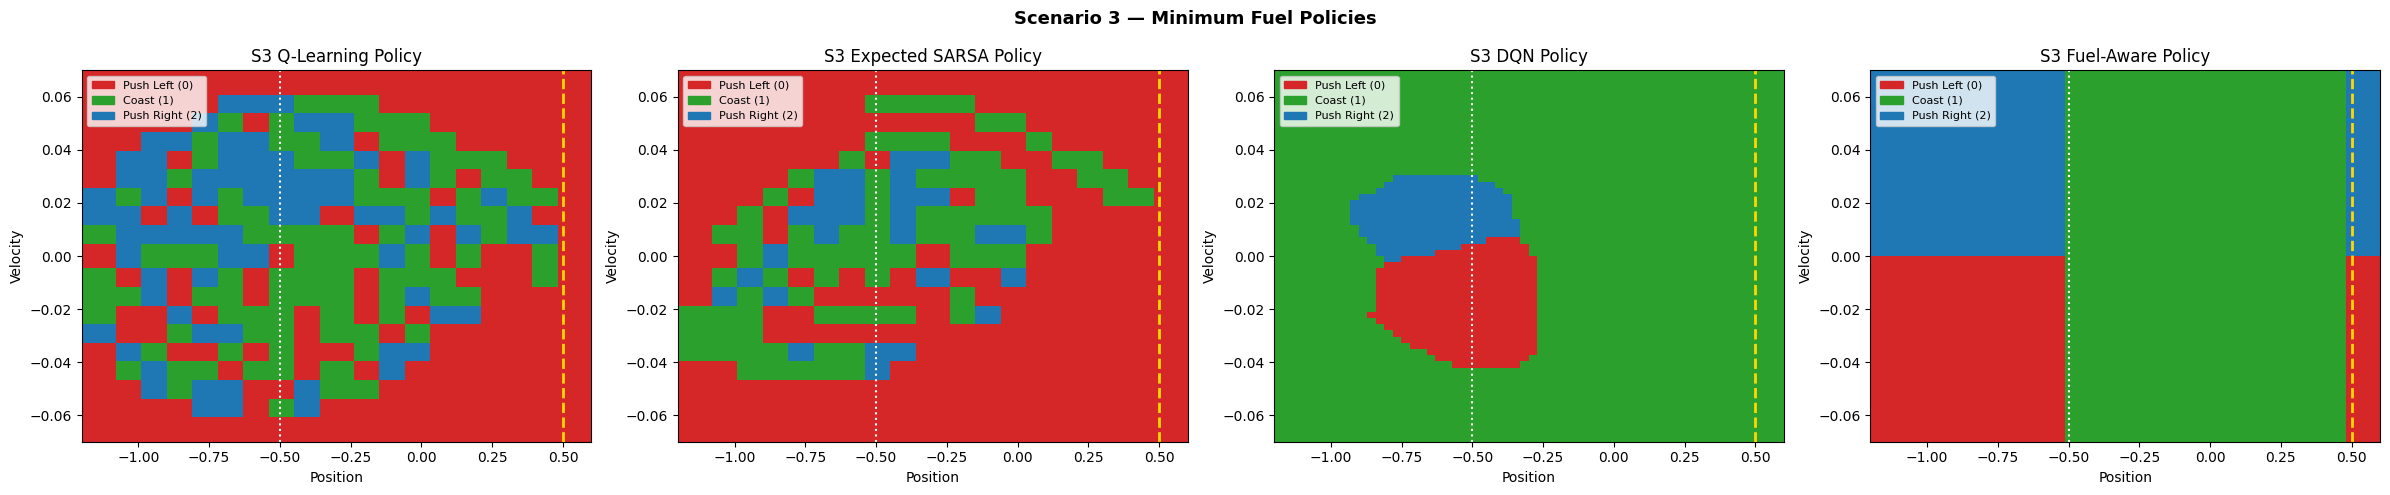

In [ ]:
n_grid = 60
pos_g = np.linspace(POS_LOW, POS_HIGH, n_grid)
vel_g = np.linspace(VEL_LOW, VEL_HIGH, n_grid)
colors = ['#d62728', '#2ca02c', '#1f77b4']
cmap = ListedColormap(colors)
action_labels = ['Push Left (0)', 'Coast (1)', 'Push Right (2)']

policy_items = [
    (ql_fn, 'S3 Q-Learning Policy', 'ql'),
    (esarsa_fn, 'S3 Expected SARSA Policy', 'esarsa'),
    (dqn_fn, 'S3 DQN Policy', 'dqn'),
    (fuel_fn, 'S3 Fuel-Aware Policy', 'fuel'),
]

fig, axes = plt.subplots(1, len(policy_items), figsize=(6 * len(policy_items), 5))
s3_grids = {}
for ax, (fn, title, key) in zip(axes, policy_items):
    grid = np.array([[fn(np.array([p, v])) for p in pos_g] for v in vel_g])
    s3_grids[key] = grid
    ax.imshow(grid, extent=[POS_LOW, POS_HIGH, VEL_LOW, VEL_HIGH],
              origin='lower', cmap=cmap, aspect='auto', vmin=0, vmax=2)
    ax.axvline(0.5, color='gold', ls='--', lw=2)
    ax.axvline(-0.5, color='white', ls=':', lw=1.5)
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_title(title)
    patches = [mpatches.Patch(color=colors[i], label=action_labels[i]) for i in range(3)]
    ax.legend(handles=patches, loc='upper left', fontsize=8)

plt.suptitle('Scenario 3 — Minimum Fuel Policies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('checkpoints/s03_policy_heatmap.png', dpi=150)
plt.show()


Final policy heatmaps show a very messy pattern for Q-learning and Expected SARSA which is not easy to interpret. On the other hand, DQN's policy chooses coast in most of the state space, and only pushes in a small region near the center which indicates the final DQN policy was very conservative about fuel use. For Fuel-aware baseline, we can see very clean rule to push left, push right, or coast. This is the easiest policy to explain. 

Loaded Scenario 1 Q-table from checkpoints/s01_qtable.pkl


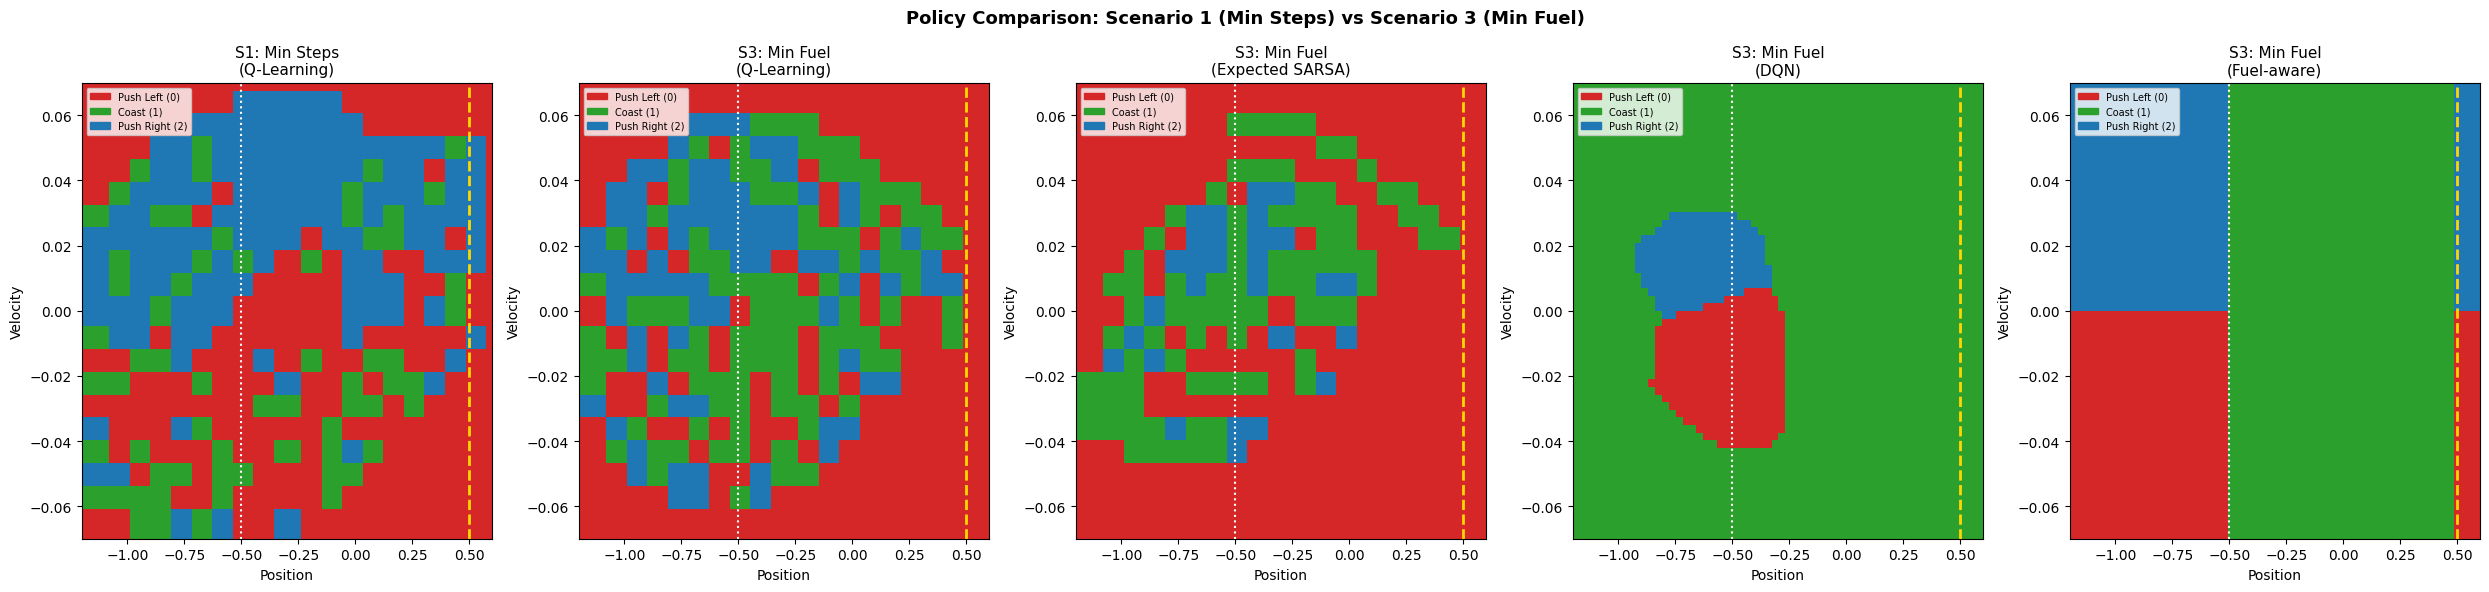

In [ ]:
try:
    with open('checkpoints/s01_qtable.pkl', 'rb') as f:
        Q_s1 = pickle.load(f)
    s1_fn = lambda state: int(np.argmax(Q_s1[discretize(state)]))
    print('Loaded Scenario 1 Q-table from checkpoints/s01_qtable.pkl')
    s1_available = True
except FileNotFoundError:
    print('S1 checkpoint not found — run scenario_01 notebook first for comparison.')
    s1_available = False

if s1_available:
    comparison_items = [
        (s1_fn, 'S1: Min Steps\n(Q-Learning)'),
        (ql_fn, 'S3: Min Fuel\n(Q-Learning)'),
        (esarsa_fn, 'S3: Min Fuel\n(Expected SARSA)'),
        (dqn_fn, 'S3: Min Fuel\n(DQN)'),
        (fuel_fn, 'S3: Min Fuel\n(Fuel-aware)'),
    ]
    fig, axes = plt.subplots(1, len(comparison_items), figsize=(5 * len(comparison_items), 6))

    for ax, (fn, title) in zip(axes, comparison_items):
        grid = np.array([[fn(np.array([p, v])) for p in pos_g] for v in vel_g])
        ax.imshow(grid, extent=[POS_LOW, POS_HIGH, VEL_LOW, VEL_HIGH],
                  origin='lower', cmap=cmap, aspect='auto', vmin=0, vmax=2)
        ax.axvline(0.5,  color='gold',  ls='--', lw=2)
        ax.axvline(-0.5, color='white', ls=':',  lw=1.5)
        ax.set_xlabel('Position')
        ax.set_ylabel('Velocity')
        ax.set_title(title, fontsize=11)
        patches = [mpatches.Patch(color=colors[i], label=action_labels[i]) for i in range(3)]
        ax.legend(handles=patches, loc='upper left', fontsize=7)

    plt.suptitle('Policy Comparison: Scenario 1 (Min Steps) vs Scenario 3 (Min Fuel)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('checkpoints/s03_comparison_heatmap.png', dpi=150)
    plt.show()

For comparison between Scenario 1 and 3 for Q-learning, we can see that now it coasts more often. 

### Policy Comparison


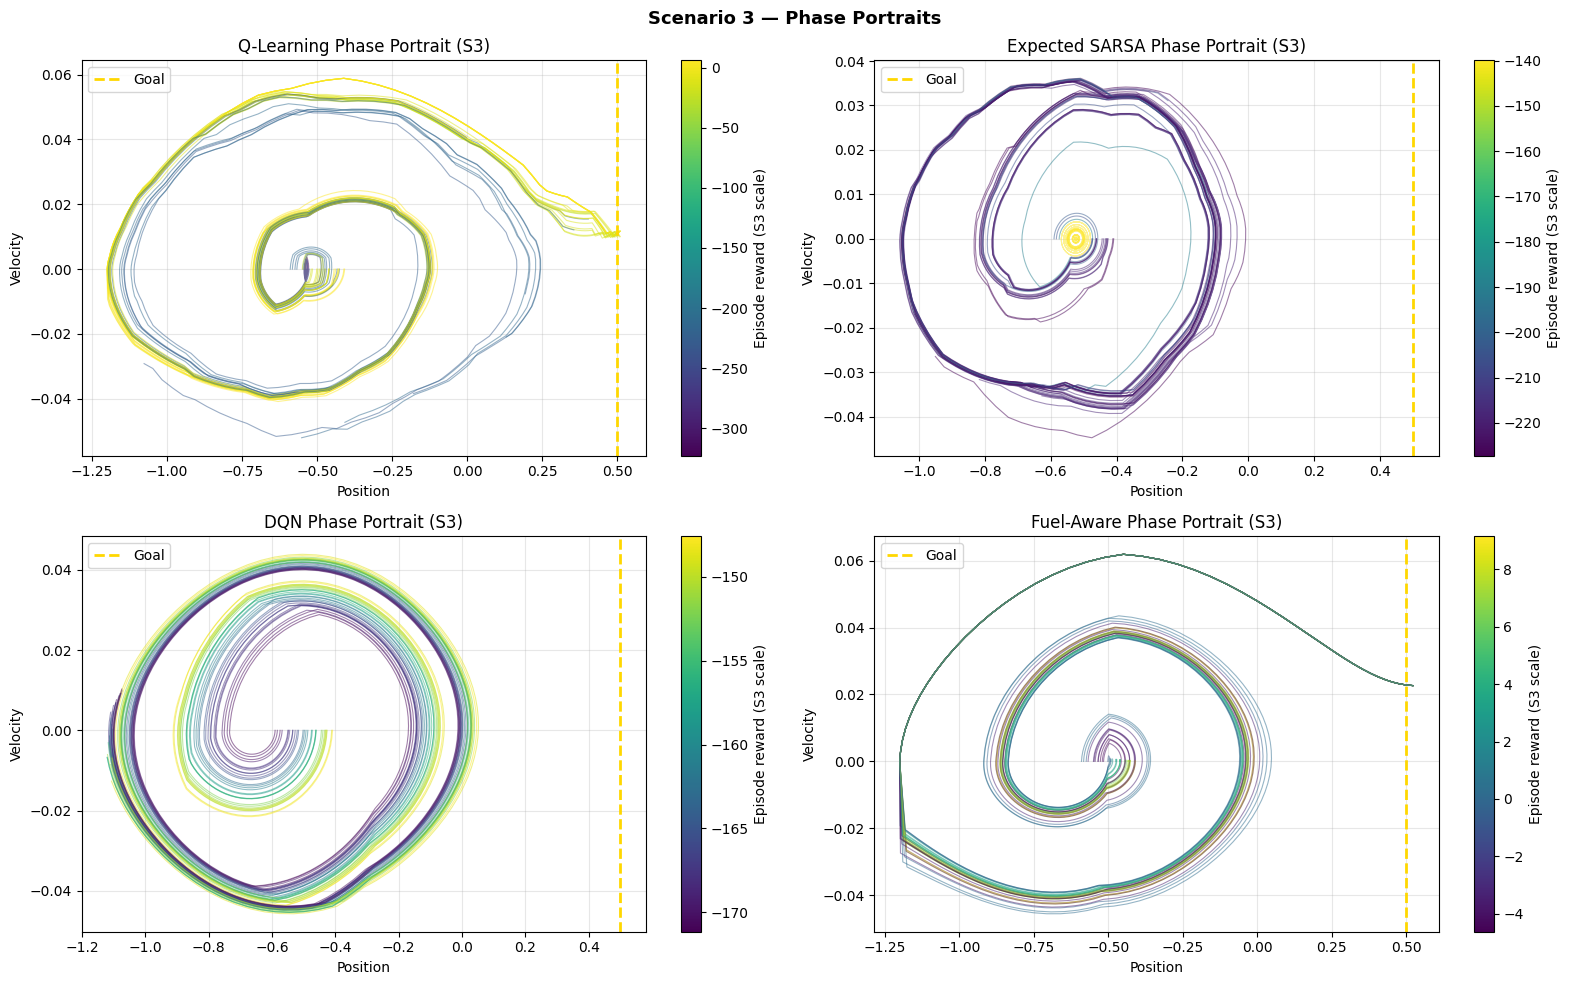

In [17]:
eval_env = make_env()
phase_items = [
    (ql_fn, 'Q-Learning Phase Portrait (S3)'),
    (esarsa_fn, 'Expected SARSA Phase Portrait (S3)'),
    (dqn_fn, 'DQN Phase Portrait (S3)'),
    (fuel_fn, 'Fuel-Aware Phase Portrait (S3)'),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, (fn, title) in zip(axes, phase_items):
    trajs = collect_trajectories(eval_env, fn, n_episodes=30, max_steps=200)
    rews = [t['total_reward'] for t in trajs]
    vmin, vmax = min(rews), max(rews)
    cmap_pp = plt.cm.viridis
    for traj in trajs:
        pos = [s[0] for s in traj['states']]
        vel = [s[1] for s in traj['states']]
        c = cmap_pp((traj['total_reward'] - vmin) / max(vmax - vmin, 1e-8))
        ax.plot(pos, vel, alpha=0.5, lw=0.8, color=c)
    sm = plt.cm.ScalarMappable(cmap=cmap_pp, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Episode reward (S3 scale)')
    ax.axvline(0.5, color='gold', ls='--', lw=2, label='Goal')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Scenario 3 — Phase Portraits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('checkpoints/s03_phase_portrait.png', dpi=150)
plt.show()


From the phase portraits, we can observe the actual motion in position and velocity. Q-learning makes large swing loops. This keeps the classic mountain-car strategy, but with some fuel saving. For Expected SARSA, loops are tighter and more limited. This looks more conservative in its fuel use and less powerful. DQN has very smooth and regular loops. However, the loops stay more central and do not push as aggressively toward the goal. Fuel-aware baseline has a clean and regular swing pattern and is a deliberate low-fuel version of the standard strategy.

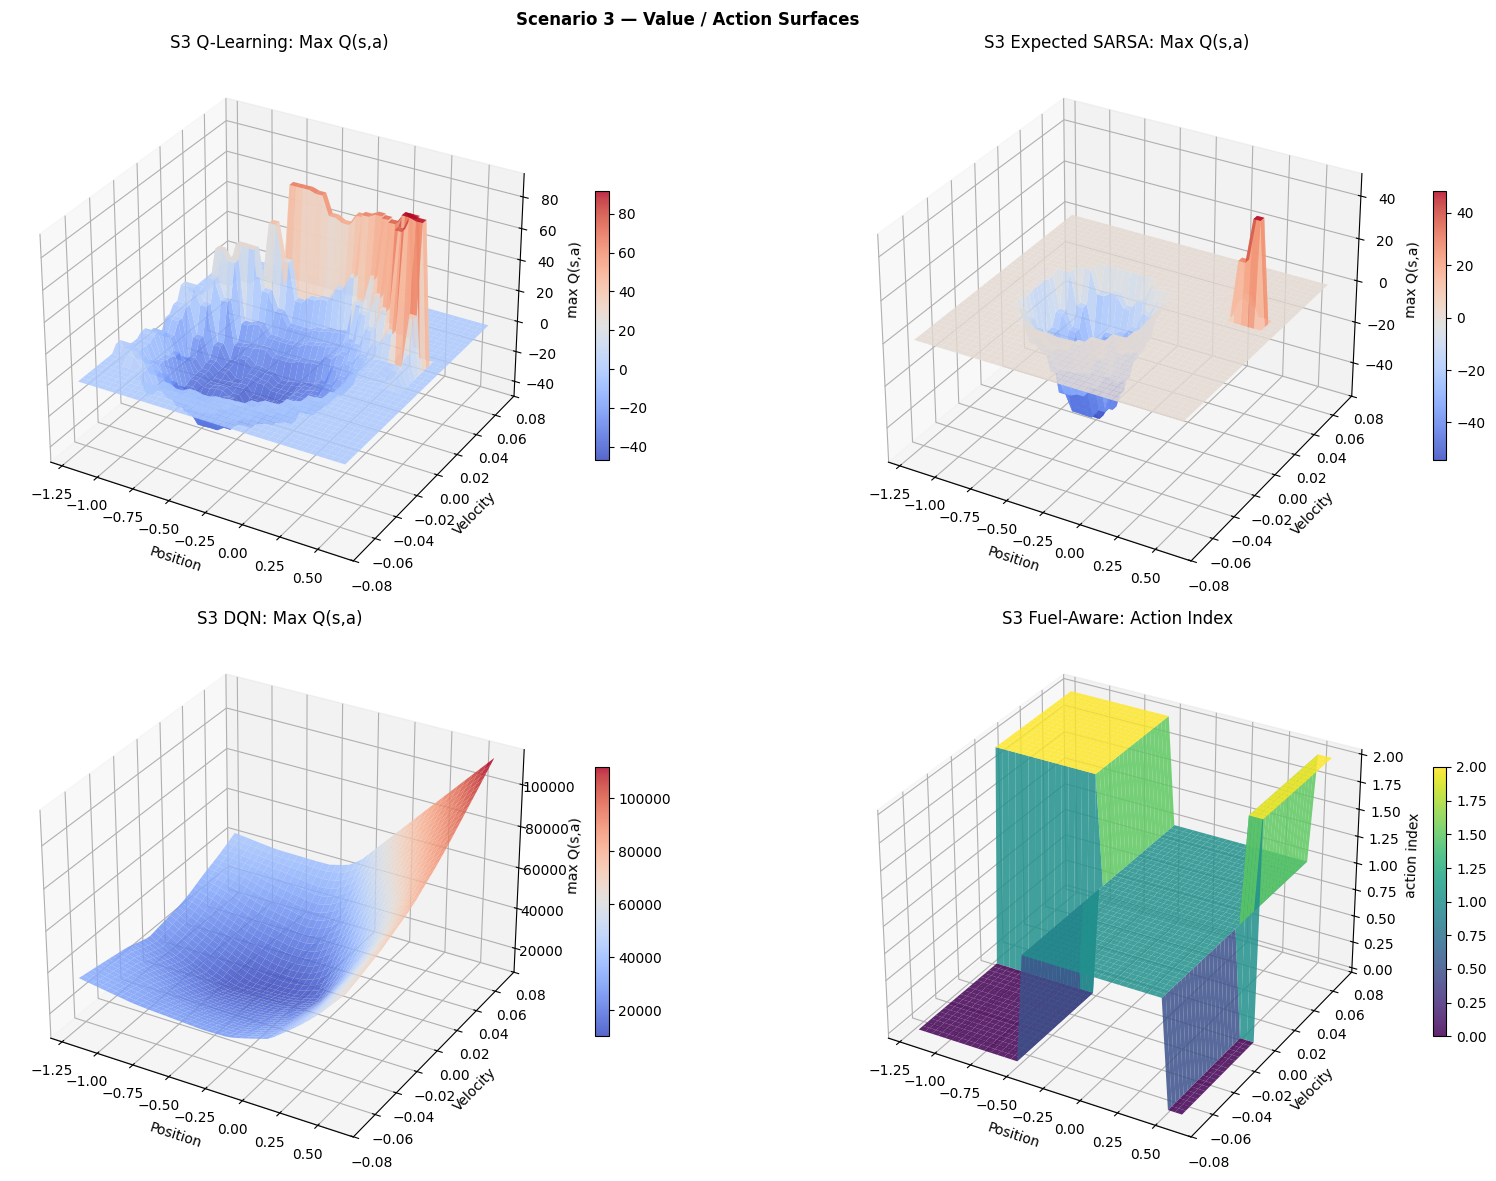

In [18]:
# Value/action surfaces for all Scenario 3 policies
n = 40
pos_g_surf = np.linspace(POS_LOW, POS_HIGH, n)
vel_g_surf = np.linspace(VEL_LOW, VEL_HIGH, n)
POS_M, VEL_M = np.meshgrid(pos_g_surf, vel_g_surf)

surface_items = [
    (lambda s: np.max(Q_table[discretize(s)]), 'S3 Q-Learning: Max Q(s,a)', 'max Q(s,a)', 'coolwarm'),
    (lambda s: np.max(Q_esarsa[discretize(s)]), 'S3 Expected SARSA: Max Q(s,a)', 'max Q(s,a)', 'coolwarm'),
    (lambda s: np.max(dqn.q_values(s)), 'S3 DQN: Max Q(s,a)', 'max Q(s,a)', 'coolwarm'),
    (lambda s: float(fuel_fn(s)), 'S3 Fuel-Aware: Action Index', 'action index', 'viridis'),
]

fig = plt.figure(figsize=(18, 12))
for idx, (value_fn, title, zlabel, cmap_name) in enumerate(surface_items, 1):
    surface = np.array([[value_fn(np.array([p, v])) for p in pos_g_surf]
                        for v in vel_g_surf])
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    surf = ax.plot_surface(POS_M, VEL_M, surface, cmap=cmap_name, alpha=0.85)
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    fig.colorbar(surf, ax=ax, shrink=0.5)

plt.suptitle('Scenario 3 — Value / Action Surfaces',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('checkpoints/s03_q_surface.png', dpi=150)
plt.show()

The bowl shape for Q learning and Expected SARSA means the middle valley does not have very good value. Values improve as the car gets into states that can lead to progress and success. The spikes for high velocity and larger x-value positions are especially valuable. 
For DQN, the value/action surface is very smooth. More rightward positions and positive velocity are valued much more.
Fuel-aware baseline is not a learned value surface. This is a hand-made action rule shown as action index. 

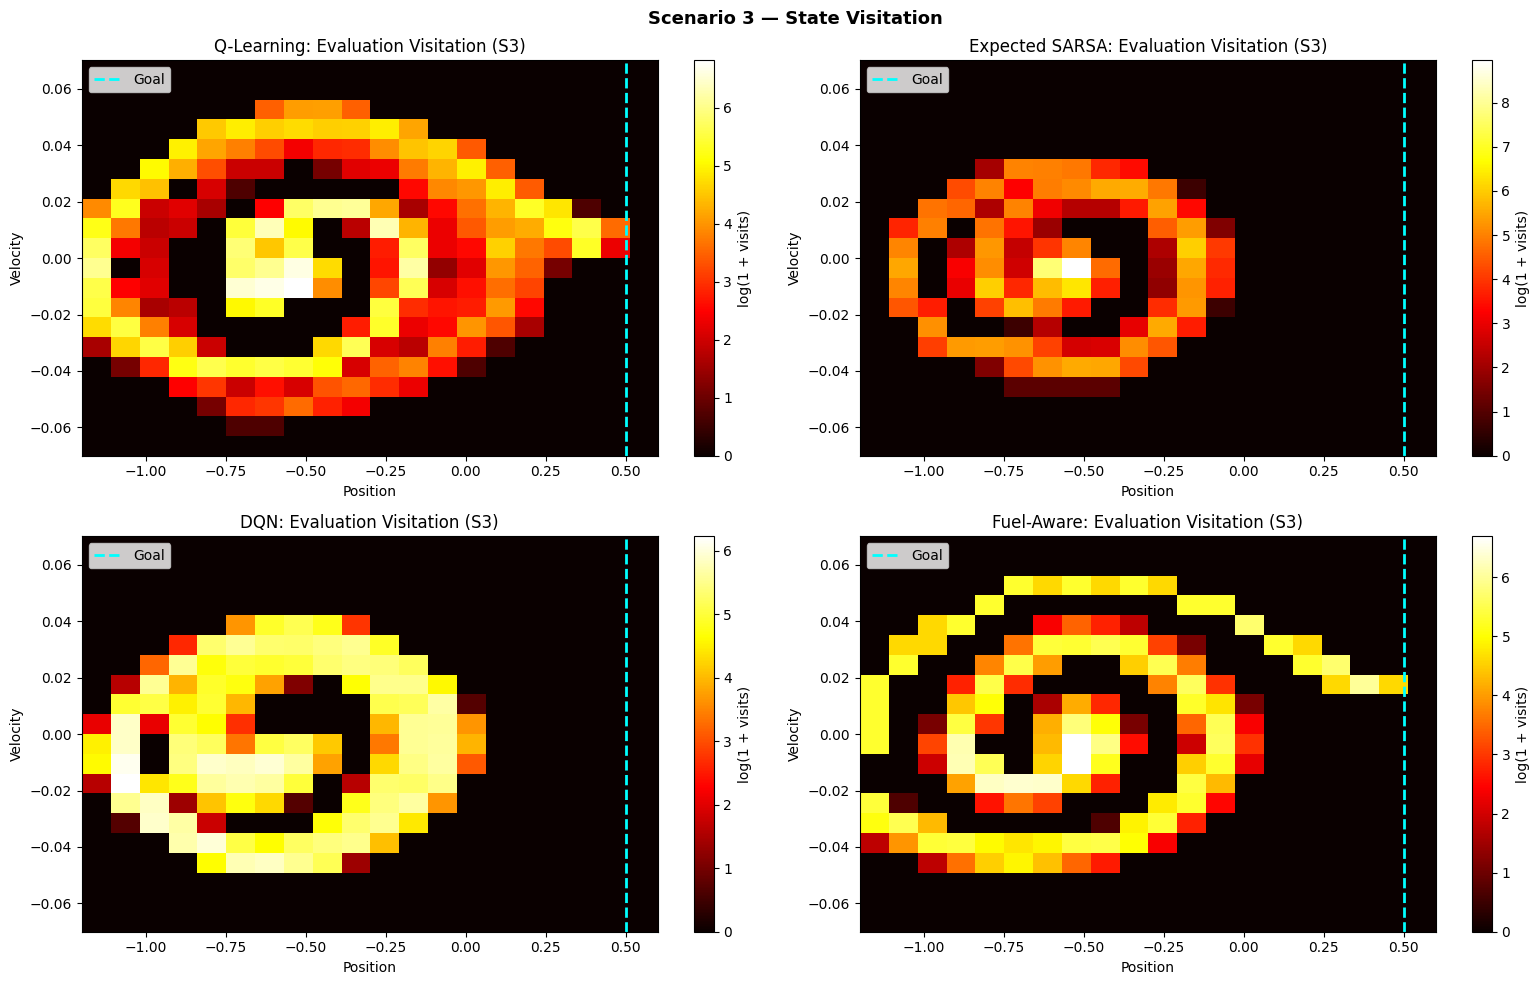

In [19]:
visit_n_bins = num_bins[0]
visitation_items = [
    ('Q-Learning', ql_fn),
    ('Expected SARSA', esarsa_fn),
    ('DQN', dqn_fn),
    ('Fuel-Aware', fuel_fn),
]
visit_grids = []
for label, fn in visitation_items:
    trajs = collect_trajectories(eval_env, fn, n_episodes=100, max_steps=200)
    visit_grids.append((label, build_visit_grid(trajs, eval_env, n_grid=visit_n_bins)))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
for ax, (label, counts) in zip(axes, visit_grids):
    im = ax.imshow(np.log1p(counts).T,
                   extent=[POS_LOW, POS_HIGH, VEL_LOW, VEL_HIGH],
                   origin='lower', cmap='hot', aspect='auto')
    plt.colorbar(im, ax=ax, label='log(1 + visits)')
    ax.axvline(0.5, color='cyan', ls='--', lw=2, label='Goal')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_title(f'{label}: Evaluation Visitation (S3)')
    ax.legend()

plt.suptitle('Scenario 3 — State Visitation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('checkpoints/s03_state_visitation.png', dpi=150)
plt.show()


For state visitation, we can see that Q-learning has a broad spiral and wider coverage and it visits many states and pushes toward the right hill. Expected SARSA has smaller and tighter visited region, which shows cautious behavior and less exploration. DQN visits a medium-sized loop but does not spread strongly toward the goal area. Fuel-aware baseline has very clear spiral, close to a classic momentum-building pattern

## Interpretability

To make the learned behavior easier to read, simple trees and feature importance plots are used.

These tools do not replace the policy. They only help explain which state variables are driving action choices.


In [20]:
def fit_policy_tree(get_action_fn, env, n_samples=8000, max_depth=5, label='Agent'):
    rng = np.random.default_rng(SEED)
    pos_s = rng.uniform(env.observation_space.low[0], env.observation_space.high[0], n_samples)
    vel_s = rng.uniform(env.observation_space.low[1], env.observation_space.high[1], n_samples)
    X = np.column_stack([pos_s, vel_s])
    y = np.array([int(get_action_fn(s)) for s in X])
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=SEED)
    dt.fit(X, y)
    acc = dt.score(X, y)
    print(f'{label}  DT fidelity (depth={max_depth}): {acc:.3f}')
    print(export_text(dt, feature_names=['position', 'velocity']))
    return dt, X, y


ql_dt, X_ql, y_ql = fit_policy_tree(ql_fn, env, label='Q-Learning (S3)')
esarsa_dt, X_esarsa, y_esarsa = fit_policy_tree(esarsa_fn, env, label='Expected SARSA (S3)')
dqn_dt, X_dqn, y_dqn = fit_policy_tree(dqn_fn, env, label='DQN (S3)')
fuel_dt, X_fuel, y_fuel = fit_policy_tree(fuel_fn, env, label='Fuel-aware policy (S3)')


Q-Learning (S3)  DT fidelity (depth=5): 0.628
|--- position <= 0.05
|   |--- velocity <= -0.05
|   |   |--- velocity <= -0.06
|   |   |   |--- class: 0
|   |   |--- velocity >  -0.06
|   |   |   |--- position <= -0.34
|   |   |   |   |--- position <= -0.83
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- position >  -0.83
|   |   |   |   |   |--- class: 2
|   |   |   |--- position >  -0.34
|   |   |   |   |--- velocity <= -0.06
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- velocity >  -0.06
|   |   |   |   |   |--- class: 0
|   |--- velocity >  -0.05
|   |   |--- velocity <= 0.06
|   |   |   |--- velocity <= 0.00
|   |   |   |   |--- velocity <= -0.02
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- velocity >  -0.02
|   |   |   |   |   |--- class: 1
|   |   |   |--- velocity >  0.00
|   |   |   |   |--- position <= -0.82
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- position >  -0.82
|   |   |   |   |   |--- class: 2
|   |   |--- velocity >  0.06
|   |   

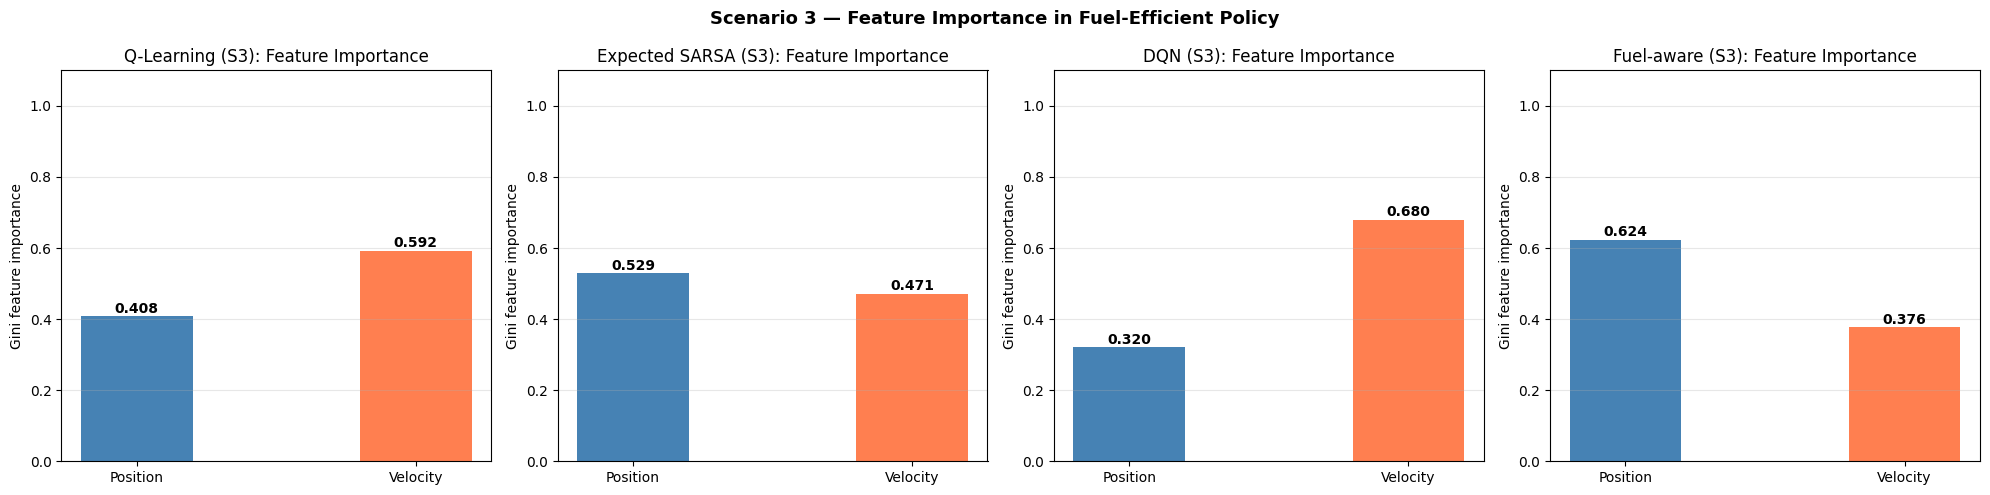

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (dt, label) in zip(axes, [
    (ql_dt, 'Q-Learning (S3)'),
    (esarsa_dt, 'Expected SARSA (S3)'),
    (dqn_dt, 'DQN (S3)'),
    (fuel_dt, 'Fuel-aware (S3)'),
]):
    imps = dt.feature_importances_
    bars = ax.bar(['Position', 'Velocity'], imps, color=['steelblue', 'coral'], width=0.4)
    for bar, imp in zip(bars, imps):
        ax.text(bar.get_x() + bar.get_width() / 2, imp + 0.01,
                f'{imp:.3f}', ha='center', fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Gini feature importance')
    ax.set_title(f'{label}: Feature Importance')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Scenario 3 — Feature Importance in Fuel-Efficient Policy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('checkpoints/s03_feature_importance.png', dpi=150)
plt.show()


The car must build momentum by moving back and forth before climbing the right hill. 

For Q-learning and DQN, the policy depends more on velocity than on position. It suggests both mostly react to motion. This describes DQN's conservative fuel-saving behavior with lots of coasting and only limited thrust.

Expected SARSA seems to make balanced decisions using both where the car is and how it is moving. 

Fuel-aware baseline's policy depends more on position, which is understandable because the baseline is a hand-designed rule with clear position-based zones for left, right, and coast



## Conclusions

In Scenario 3, the learned agents struggled to balance fuel efficiency and task success. Q-learning performed best among the learned methods because it was the only one that reached the goal in a few episodes, although it used the most thrust. Expected SARSA and DQN were more fuel-efficient, but both became too conservative and failed to solve the task. The fuel-aware resonant baseline gave the strongest overall result, achieving perfect success while still keeping thrust usage lower than Q-learning.
